# PARIKALP 2026 — EDA & Data Cleaning
**Team Role:** EDA, Physics Validation, Data Cleaning

**Dataset:** Exoplanet dataset — 39,913 rows × 96 columns

**Targets to predict:** `pl_rade` (planet radius) and `pl_bmasse` (planet mass)

**Final goal:** After cleaning, teammates will use this data to build a regression model and calculate escape velocity using `v_e = sqrt(2GM/R)`

## Step 1 — Mount Drive and Load Files

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Confirm all competition files are accessible
folder_path = '/content/drive/MyDrive/compition'
for file in os.listdir(folder_path):
    print(file)

1. Data Analytics Rules.pdf
8e44d231-a7c0-4ff1-9c41-ba4fe6cead6b.pdf
2. Problem Statement and Marking Scheme.pdf
4. Data Dictionary and Feature Documentation (2).pdf
5. Astronomical Constants.pdf
3. Dataset - DA'26.csv
clean_checkpoint.csv


In [3]:
# Load the main dataset
df = pd.read_csv(f"{folder_path}/3. Dataset - DA'26.csv")
print('Dataset loaded successfully')

Dataset loaded successfully


## Step 2 — Initial Data Inspection
Before doing anything, we first understand what we have — shape, data types, missing values, and basic statistics.

This corresponds to **Section 1.1 (Data Inspection)** of the marking scheme.

In [4]:
# Dataset dimensions — how many rows and columns
print('Shape:', df.shape)
print('Total cells:', df.shape[0] * df.shape[1])

Shape: (39913, 96)
Total cells: 3831648


In [5]:
# First 5 rows — quick visual of what the data looks like
df.head()

,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbeccen,pl_orbincl,pl_insol,pl_eqt,...,releasedate,disc_pubdate,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_rade,pl_bmasse
0,4.765591,0.000028,-0.000028,0.0522,NaN,NaN,0.00,88.81,439.4200,1168.00,...,2015-08-25,2022-02,0.0,0.0,0.0,0.0,0.0,0.0,0.93000,0.76
1,3.700633,0.000018,-0.000018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2018-09-25,2022-02,0.0,0.0,0.0,0.0,0.0,0.0,2.30200,4.10
2,4.225350,0.000022,-0.000022,NaN,NaN,NaN,NaN,NaN,342.3014,1097.04,...,2023-03-28,2016-05,0.0,0.0,0.0,0.0,0.0,0.0,8.88932,59.00
3,4.510045,0.000019,-0.000019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2019-04-18,2016-05,0.0,0.0,0.0,0.0,0.0,0.0,2.30200,2.73
4,85.313900,0.001700,-0.001700,NaN,NaN,NaN,0.01,NaN,NaN,NaN,...,2021-11-10,2013-01,0.0,0.0,0.0,0.0,0.0,0.0,8.98000,4.00


In [6]:
# Data types and non-null counts per column
# Non-null count tells us how many rows have actual data (missing = 39913 - non-null count)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39913 entries, 0 to 39912
Data columns (total 96 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pl_orbper            36509 non-null  float64
 1   pl_orbpererr1        34803 non-null  float64
 2   pl_orbpererr2        34802 non-null  float64
 3   pl_orbsmax           22270 non-null  float64
 4   pl_orbsmaxerr1       7795 non-null   float64
 5   pl_orbsmaxerr2       7794 non-null   float64
 6   pl_orbeccen          18975 non-null  float64
 7   pl_orbincl           17674 non-null  float64
 8   pl_insol             17333 non-null  float64
 9   pl_eqt               17506 non-null  float64
 10  pl_imppar            17445 non-null  float64
 11  pl_trandur           22581 non-null  float64
 12  pl_ratror            21750 non-null  float64
 13  pl_ratrorerr1        21434 non-null  float64
 14  pl_ratrorerr2        21434 non-null  float64
 15  st_mass              33535 non-null 

In [7]:
# Data type of every column
df.dtypes

,0
pl_orbper,float64
pl_orbpererr1,float64
pl_orbpererr2,float64
pl_orbsmax,float64
pl_orbsmaxerr1,float64
...,...
pl_nespec,float64
pl_ntranspec,float64
pl_ndispec,float64
pl_rade,float64


In [8]:
# Count of missing values per column — sorted worst to best
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

pl_orbsmaxerr2    32119
pl_orbsmaxerr1    32118
pl_insol          22580
pl_imppar         22468
pl_eqt            22407
                  ...  
pl_nespec            52
disc_facility        23
disc_pubdate         23
soltype              23
disc_year             2
Length: 85, dtype: int64


In [9]:

pd.set_option('display.max_columns', None)
df.describe()

,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbeccen,pl_orbincl,pl_insol,pl_eqt,pl_imppar,pl_trandur,pl_ratror,pl_ratrorerr1,pl_ratrorerr2,st_mass,st_masserr1,st_masserr2,st_rad,st_raderr1,st_raderr2,st_teff,st_tefferr1,st_tefferr2,st_logg,st_loggerr1,st_loggerr2,st_met,st_meterr1,st_meterr2,st_dens,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_bmag,sy_bmagerr1,sy_bmagerr2,sy_jmag,sy_jmagerr1,sy_jmagerr2,sy_hmag,sy_hmagerr1,sy_hmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_w1mag,sy_w1magerr1,sy_w1magerr2,sy_w2mag,sy_w2magerr1,sy_w2magerr2,sy_w3mag,sy_w3magerr1,sy_w3magerr2,sy_w4mag,sy_gaiamag,sy_tmag,sy_snum,sy_pnum,sy_mnum,disc_year,sy_dist,sy_disterr1,sy_disterr2,sy_plx,sy_pm,sy_pmra,sy_pmdec,glon,glat,cosmic_noise_1,cosmic_noise_2,pl_orbper_noisy,pl_orbsmax_noisy,orbital_size_score,stellar_scale_score,rowid,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_rade,pl_bmasse
count,3.650900e+04,3.480300e+04,3.480200e+04,22270.000000,7795.000000,7794.000000,18975.000000,17674.000000,17333.000000,17506.000000,17445.000000,22581.000000,21750.000000,21434.000000,21434.000000,33535.000000,27998.000000,27843.000000,36489.000000,30785.000000,30632.000000,36323.000000,35322.000000,35062.000000,30936.000000,25482.000000,25481.000000,24987.000000,24312.000000,24312.000000,22570.000000,39020.000000,39007.000000,39006.000000,38350.00000,38345.000000,38345.000000,38988.000000,38890.000000,38890.000000,39017.000000,38879.000000,38879.000000,39015.000000,38773.000000,38773.000000,36870.000000,36773.000000,36773.000000,36871.000000,36790.000000,36790.000000,36869.000000,27316.000000,27316.000000,36866.000000,38722.000000,39027.000000,39913.000000,39913.000000,39913.0,39911.000000,39007.000000,38144.000000,38144.000000,37411.000000,38899.000000,38899.000000,38899.000000,39861.000000,39861.000000,39913.000000,39913.000000,3.650900e+04,22270.000000,2.138200e+04,31294.000000,39913.000000,39861.000000,39861.000000,39861.000000,39861.000000,39861.000000,39861.000000,3.991300e+04,39682.000000
mean,1.198824e+04,1.386161e+04,-3.267188e+03,4.757800,1.037986,-0.698837,0.047905,87.450796,362.256303,880.597757,0.458060,4.030841,0.061903,0.055443,-0.015192,0.925378,0.103386,-0.090056,1.150747,0.201294,-0.126043,21829.169844,115.646451,-117.532747,4.411913,0.099118,-0.152529,-0.022005,0.141419,-0.152420,3.036828,13.512935,0.114994,-0.115570,14.33527,0.080295,-0.080295,11.949633,0.030051,-0.029854,11.568903,0.031361,-0.031242,11.481313,0.034928,-0.034455,11.618028,0.029426,-0.029426,11.659459,0.026170,-0.026170,11.377138,0.182590,-0.182590,8.913672,13.275513,12.721379,1.086187,1.917546,0.0,2015.638846,1166.989771,36.904377,-38.492158,7.013025,57.953625,3.614174,-16.610018,106.118341,9.705724,5007.014879,-4.155122,1.640612e+04,4.777284,1.431019e+04,2.110594,19957.000000,0.471463,0.200246,0.115276,0.259828,0.237952,0.008153,1.288243e+08,202.457159
std,2.105127e+06,2.519538e+06,5.372766e+05,179.790139,59.125742,25.488372,0.127360,8.307122,1378.717696,429.060721,2.557071,2.555930,1.004435,1.620271,0.465619,0.346799,0.607500,0.607233,1.780539,0.863378,0.600925,126560.459639,84.743149,86.430066,0.301383,0.110832,0.138806,0.226970,0.097306,0.104742,9.479842,2.456259,0.149420,0.178299,2.52069,0.090143,0.090143,2.338822,0.121932,0.115261,2.348605,0.083563,0.086077,2.364828,0.183774,0.175245,2.079671,0.032551,0.032551,2.098718,0.019725,0.019725,1.879967,0.146859,0.146859,0.951900,2.395417,2.368722,0.312093,1.239019,0.0,4.140699,1818.132315,158.112886,183.561562,23.515520,256.371435,187.148647,183.770090,74.443680,21.549921,1501.937206,577.190425,2.348076e+06,179.862611,1.925550e+06,2.032874,11522.034984,3.791250,0.903936,0.799450,1.933568,1.681397,0.220861,2.573677e+10,745.746875
min,9.070629e-02,0.000000e+00,-1.000000e+08,0.004400,0.000000,-2060.000000,-0.011000,-39.930000,0.000300,34.000000,-0.941000,-0.068000,0.003223,0.000000,-28.824688,-0.023015,0.000000,-97.100000,0.012876,0.000000,-73.630000,390.881699,0.000000,-6064.900000,0

## Step 3 — Physics Validation & Fixing Violations
Before any modeling, we check if the data violates known physical laws.
If a value is physically impossible, it is either a data entry error or a unit mismatch.

This corresponds to **Section 1.4 (Visualization)** of the marking scheme — identifying physics law violations through visualization.

### 3.1 — `sy_dist` (System Distance in Parsecs)
**Physical rule:** Distance from Earth cannot be negative. It must be a positive value.

**Expected range:** According to the Astronomical Constants PDF, the maximum distance in this dataset is ~8,500 parsecs (Galactic Bulge regions).

**Suspected issue:** The problem statement hints that one distance parameter was logged in two different units (parsecs and light-years). 1 parsec = 3.26 light-years.

In [10]:
# Step 1: Check the distribution of sy_dist before any fix
print('sy_dist statistics BEFORE fix:')
print(df['sy_dist'].describe())
print(f"\nNegative values: {(df['sy_dist'] < 0).sum()}")

sy_dist statistics BEFORE fix:
count    39007.000000
mean      1166.989771
std       1818.132315
min     -29869.553435
25%        316.119267
50%        733.547098
75%       1350.297853
max      27221.405247
Name: sy_dist, dtype: float64

Negative values: 1005


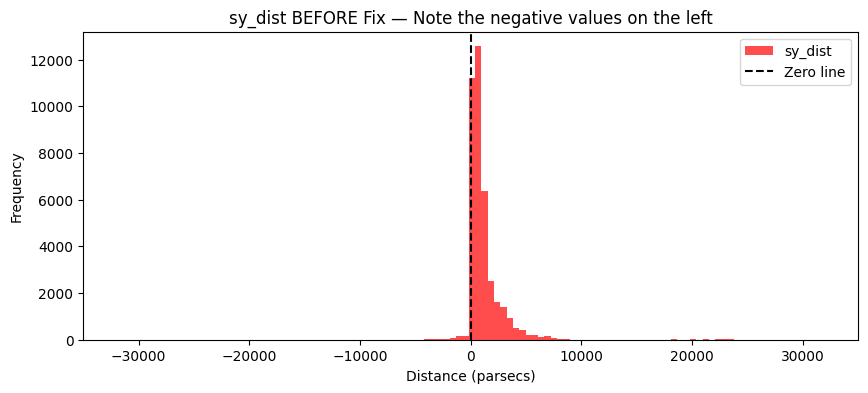

In [11]:
# Step 2: Visualize sy_dist BEFORE fix — histogram shows negative values clearly
plt.figure(figsize=(10,4))
df['sy_dist'].plot(kind='hist', bins=100, color='red', alpha=0.7)
plt.xlim(-35000, 35000)
plt.title('sy_dist BEFORE Fix — Note the negative values on the left')
plt.xlabel('Distance (parsecs)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='black', linestyle='--', label='Zero line')
plt.legend()
plt.show()

In [12]:
# Step 3: Fix negative values — take absolute value
# Reasoning: Distance cannot be negative. The magnitude is realistic,
# suggesting a sign entry error rather than a completely wrong value.
df['sy_dist'] = df['sy_dist'].abs()

# Step 4: Check how many values exceed the expected parsec maximum (~8504)
# These are likely recorded in light-years instead of parsecs
light_year_candidates = df[df['sy_dist'] > 8504]['sy_dist'].count()
print(f'Values above 8504 parsecs (likely in light-years): {light_year_candidates}')

Values above 8504 parsecs (likely in light-years): 210


In [13]:
# Step 5: Convert values above 8504 from light-years to parsecs
# Source: Astronomical Constants PDF states 1 parsec = 3.26 light-years
# Only values above the expected max are converted — not the entire column
# This is a minimal-change strategy to avoid incorrectly converting valid extreme values
df.loc[df['sy_dist'] > 8504, 'sy_dist'] /= 3.26

print('Conversion applied. New sy_dist statistics:')
print(df['sy_dist'].describe())

Conversion applied. New sy_dist statistics:
count    39007.000000
mean      1143.825172
std       1288.057737
min          0.033312
25%        330.758310
50%        750.527924
75%       1366.759302
max       9162.439704
Name: sy_dist, dtype: float64


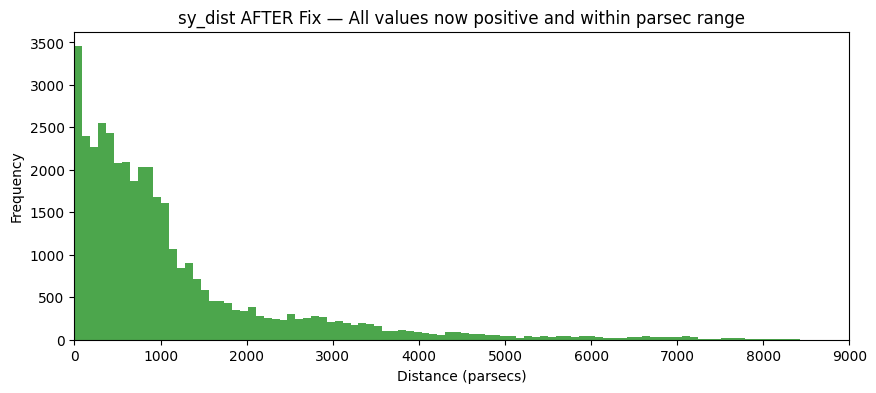

In [14]:
# Step 6: Visualize sy_dist AFTER fix — all values should now be positive and within range
plt.figure(figsize=(10,4))
df['sy_dist'].plot(kind='hist', bins=100, color='green', alpha=0.7)
plt.xlim(0, 9000)
plt.title('sy_dist AFTER Fix — All values now positive and within parsec range')
plt.xlabel('Distance (parsecs)')
plt.ylabel('Frequency')
plt.show()

### 3.2 — `pl_orbeccen` (Orbital Eccentricity)
**Physical rule:** Eccentricity must be between 0 and 1 (inclusive).
- 0 = perfectly circular orbit
- Values closer to 1 = highly elongated orbit
- Values outside 0–1 are physically impossible

**Note:** This column also has ~52% missing values — those will be handled in the imputation phase.

In [15]:
# Check distribution
print(df['pl_orbeccen'].describe())
print(f"\nMissing values: {df['pl_orbeccen'].isna().sum()}")
print(f"Valid values (0 to 1): {df[(df['pl_orbeccen'] >= 0) & (df['pl_orbeccen'] <= 1)]['pl_orbeccen'].count()}")
print(f"Invalid values above 1: {(df['pl_orbeccen'] > 1).sum()}")
print(f"Invalid values below 0: {(df['pl_orbeccen'] < 0).sum()}")

count    18975.000000
mean         0.047905
std          0.127360
min         -0.011000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.970000
Name: pl_orbeccen, dtype: float64

Missing values: 20938
Valid values (0 to 1): 18974
Invalid values above 1: 0
Invalid values below 0: 1


In [16]:
# Fix: 1 value found below 0 — no physical basis to assume true value
# No formula exists to reconstruct eccentricity from other columns
# Decision: convert to NaN and handle with missing values later
df.loc[df['pl_orbeccen'] < 0, 'pl_orbeccen'] = None
print(f'Invalid values remaining: {(df["pl_orbeccen"] < 0).sum()}')

Invalid values remaining: 0


### 3.3 — `pl_orbincl` (Orbital Inclination)
**Physical rule:** Inclination is an angle measured in degrees — valid range is 0° to 180°.
Values outside this range are physically impossible.

**Note:** This column has ~56% missing values — those will be handled in the imputation phase.

In [17]:
# Check distribution
print(df['pl_orbincl'].describe())
print(f"\nMissing values: {df['pl_orbincl'].isna().sum()}")
print(f"Valid values (0 to 180): {df[(df['pl_orbincl'] >= 0) & (df['pl_orbincl'] <= 180)]['pl_orbincl'].count()}")
print(f"Invalid values: {((df['pl_orbincl'] < 0) | (df['pl_orbincl'] > 180)).sum()}")

count    17674.000000
mean        87.450796
std          8.307122
min        -39.930000
25%         87.191000
50%         88.810000
75%         89.810000
max        178.300000
Name: pl_orbincl, dtype: float64

Missing values: 22239
Valid values (0 to 180): 17673
Invalid values: 1


In [18]:
# Fix: 1 value found at -39 degrees — physically impossible
# No scientific basis to assume -39 means +39 (unlike sy_dist where pattern was clear)
# Decision: convert to NaN and handle with missing values later
df.loc[df['pl_orbincl'] < 0, 'pl_orbincl'] = None
print(f'Invalid values remaining: {(df["pl_orbincl"] < 0).sum()}')

Invalid values remaining: 0


### 3.4 — `st_mass` (Stellar Mass)
**Physical rule:** Mass cannot be negative — a star with negative mass has no physical meaning.

**Expected:** All values should be positive (in units of Solar masses).

In [19]:
# Check for negative mass values
negative_mass = df[df['st_mass'] < 0]['st_mass']
print(f'Negative st_mass values found: {len(negative_mass)}')
print(negative_mass)

Negative st_mass values found: 3
1079    -0.002497
22455   -0.000331
32504   -0.023015
Name: st_mass, dtype: float64


In [20]:
# Fix: 3 values found with small negative mass (-0.002, -0.0003, -0.023)
# The magnitude of all 3 is realistic for a star mass
# Conclusion: sign entry error, not a fundamentally wrong measurement
# Fix: take absolute value
df['st_mass'] = df['st_mass'].abs()
print(f'Negative values remaining: {(df["st_mass"] < 0).sum()}')

Negative values remaining: 0


### 3.5 — Other Physical Columns
Checked: `pl_orbsmax`, `pl_orbper`, `st_rad`, `st_teff`

All must be positive (distance, time period, radius, temperature in Kelvin).

**Result:** No invalid values found in any of these columns.

In [21]:
# Verify minimum values — all should be positive
cols_to_check = ['pl_orbsmax', 'pl_orbper', 'st_rad', 'st_teff']
for col in cols_to_check:
    min_val = df[col].min()
    status = 'OK' if min_val >= 0 else 'PROBLEM'
    print(f'{col}: min = {min_val:.4f} [{status}]')

pl_orbsmax: min = 0.0044 [OK]
pl_orbper: min = 0.0907 [OK]
st_rad: min = 0.0129 [OK]
st_teff: min = 390.8817 [OK]


## Step 4 — Drop Useless Columns
Three categories of columns are removed before modeling:

1. **Noisy/Decoy columns** — artificially corrupted versions of real columns (name contains 'noisy' or 'noise')
2. **Metadata columns** — labels, IDs, dates — describe the record, not the physics
3. **Data leakage columns** — `pl_ratror` is mathematically derived from `pl_rade` (a target variable). Using it as a feature would let the model 'see the answer' during training, which is penalized by competition rules.

In [22]:
# Drop all three categories in one operation
df.drop(columns=[
    # Noisy/decoy columns — corrupted versions of real columns
    'cosmic_noise_1', 'cosmic_noise_2',
    'pl_orbper_noisy', 'pl_orbsmax_noisy',

    # Metadata — no predictive value, just labels/IDs/dates
    'rowid', 'pl_name', 'hostname', 'pl_letter',
    'rowupdate', 'pl_pubdate', 'releasedate', 'disc_pubdate',
    'discoverymethod', 'disc_year', 'disc_facility', 'soltype',

    # Data leakage — pl_ratror = pl_rade / st_rad (derived from target)
    'pl_ratror', 'pl_ratrorerr1', 'pl_ratrorerr2'
], inplace=True)

print(f'Columns after dropping: {df.shape[1]}')
print(f'Rows unchanged: {df.shape[0]}')

Columns after dropping: 77
Rows unchanged: 39913


## Step 5 — Export Checkpoint for Team
This is the cleaned dataset after physics validation and column removal.

**What's done:**
- `sy_dist`: negatives fixed, light-year values converted to parsecs
- `pl_orbeccen`: 1 invalid value → NaN
- `pl_orbincl`: 1 invalid value → NaN
- `st_mass`: 3 negative values → absolute value
- 19 useless columns dropped (noisy, metadata, leakage)

**What's NOT done yet (coming in next phase):**
- Missing value imputation (~52% missing in some columns)
- Feature engineering
- Outlier analysis

Teammates can start building their pipeline structure on this file.

In [23]:
# Final shape confirmation
print('Final dataset shape:', df.shape)
print('\nMissing values summary (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

Final dataset shape: (39913, 77)

Missing values summary (top 10):
pl_orbsmaxerr2        32119
pl_orbsmaxerr1        32118
pl_insol              22580
pl_imppar             22468
pl_eqt                22407
pl_orbincl            22240
pl_orbeccen           20939
orbital_size_score    18531
pl_orbsmax            17643
st_dens               17343
dtype: int64


In [24]:
# Export clean checkpoint CSV for teammates
output_path = f"{folder_path}/clean_checkpoint.csv"
df.to_csv(output_path, index=False)
print(f'Checkpoint exported to: {output_path}')

Checkpoint exported to: /content/drive/MyDrive/compition/clean_checkpoint.csv


## 📊 Step 6 — Correlation Analysis

**What we are doing:** Checking which columns are most related to our two targets `pl_rade` and `pl_bmasse`.

**Why:** Before feature engineering, we need to know which columns actually carry useful signal. Columns with near-zero correlation are weak predictors.

**Teammate note:** Do NOT skip this section — correlation results directly influenced which features were engineered and which columns were prioritized.

In [25]:
# Calculate the correlation of 'pl_rade' with all other numerical columns
correlations = df.corr(numeric_only=True)['pl_rade'].sort_values(ascending=False)

# Display the top 10 positive and negative correlations (excluding self-correlation)
print('Top 10 positive correlations with pl_rade:')
print(correlations[1:11])

print('\nTop 10 negative correlations with pl_rade:')
print(correlations[-10:])

Top 10 positive correlations with pl_rade:
pl_imppar       0.186746
st_dens         0.061212
sy_vmagerr1     0.034497
st_meterr1      0.011112
sy_w3magerr2    0.008363
sy_bmag         0.008014
sy_gaiamag      0.006457
sy_tmag         0.006069
sy_vmag         0.005773
sy_jmag         0.005601
Name: pl_rade, dtype: float64

Top 10 negative correlations with pl_rade:
st_tefferr2    -0.002871
sy_pnum        -0.003707
st_mass        -0.004583
pl_eqt         -0.005366
st_met         -0.006076
sy_w3magerr1   -0.008363
st_meterr2     -0.010261
sy_vmagerr2    -0.028894
pl_orbincl     -0.055179
sy_mnum              NaN
Name: pl_rade, dtype: float64


In [26]:
print(df[['pl_rade', 'st_rad']].corr())

          pl_rade    st_rad
pl_rade  1.000000 -0.001393
st_rad  -0.001393  1.000000


Expected strong correlation between stellar radius and planet radius, but found near-zero correlation. This suggests planet size is not strongly determined by star size alone across the full dataset — other factors dominate.


In [27]:
print(df[['pl_rade', 'pl_bmasse']].corr())

           pl_rade  pl_bmasse
pl_rade    1.00000   -0.00129
pl_bmasse -0.00129    1.00000


In [28]:
print(df[['pl_rade', 'pl_bmasse']].describe())

            pl_rade     pl_bmasse
count  3.991300e+04  39682.000000
mean   1.288243e+08    202.457159
std    2.573677e+10    745.746875
min    2.700000e-01      0.020000
25%    1.920000e+00      3.494942
50%    2.302000e+00      7.080000
75%    2.836856e+00     24.600000
max    5.141752e+12   9534.852210


### ⚠️ Target Variable Anomaly Found — `pl_rade`

**Finding:** `pl_rade` max value was 5.14 TRILLION Earth radii — physically impossible.

The Astronomical Constants PDF states the maximum planet radius in this dataset is ~27.35 Jupiter radii = ~301 Earth radii.

Anything above 301 is corrupted observational data. **Next cell drops those rows.**

In [29]:
df['pl_rade'].sort_values(ascending=False).head(20)

,pl_rade
39222,5.141752e+12
26199,6.502510e+05
18838,2.675500e+05
21865,9.712037e+04
28788,7.522349e+04
3807,3.764122e+04
18518,3.481226e+04
23462,3.307068e+04
31068,3.246732e+04
14455,3.224308e+04


In [30]:
print((df['pl_rade'] > 301).sum())

print(((df['pl_rade'] < 301) & (df['pl_rade'] > 0)).sum())

1205
38708


In [31]:
df = df[df['pl_rade'] <= 301]
print(f'DataFrame shape after dropping rows: {df.shape}')

DataFrame shape after dropping rows: (38708, 77)


### ✅ `pl_rade` Cleaned

**Rows dropped:** 1,205 rows with impossible planet radius values (above 301 Earth radii).

**Rows remaining:** ~38,700+ rows — more than enough for reliable model training.

**`pl_bmasse` check:** Max value is 9,534 Earth masses — within physical range for massive gas giants. No rows dropped for mass.

In [32]:
df['pl_bmasse'].sort_values(ascending=False).head(10)

,pl_bmasse
17652,9534.852210
1734,9375.938007
9424,9375.938007
22283,9344.155166
38972,9344.155166
2684,9333.031172
36639,9217.023803
31313,9217.023803
8121,9057.770000
27740,9045.396463


In [33]:
corr = df.corr(numeric_only=True)[['pl_rade', 'pl_bmasse']].sort_values('pl_rade', ascending=False)
print(corr)

               pl_rade  pl_bmasse
pl_rade       1.000000   0.141704
pl_eqt        0.289836   0.219978
pl_nespec     0.175233   0.117620
pl_insol      0.155263   0.138933
pl_bmasse     0.141704   1.000000
...                ...        ...
sy_bmag      -0.100779  -0.359592
sy_pnum      -0.124581  -0.069189
st_logg      -0.128436  -0.261640
sy_w3magerr1 -0.137461  -0.208164
sy_mnum            NaN        NaN

[77 rows x 2 columns]


In [34]:
df['sy_mnum'].describe()

,sy_mnum
count,38708.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


### 🗑️ `sy_mnum` Dropped — Zero Variance Column

**Finding:** `sy_mnum` (number of moons) has mean=0, std=0, min=0, max=0 — every single value is zero.

A column with zero variance gives the model zero information. **Dropped immediately.**

In [35]:
corr = df.corr(numeric_only=True)[['pl_rade', 'pl_bmasse']].abs().sort_values('pl_rade', ascending=False)
print(corr)

             pl_rade  pl_bmasse
pl_rade     1.000000   0.141704
pl_eqt      0.289836   0.219978
pl_nespec   0.175233   0.117620
pl_insol    0.155263   0.138933
pl_bmasse   0.141704   1.000000
...              ...        ...
sy_pmdec    0.006106   0.018612
pl_orbsmax  0.003874   0.128589
st_raderr1  0.002128   0.091565
st_raderr2  0.001035   0.154259
sy_mnum          NaN        NaN

[77 rows x 2 columns]


In [36]:
corr = df.corr(numeric_only=True)[['pl_rade', 'pl_bmasse']].abs().sort_values('pl_bmasse', ascending=False)
print(corr)

                pl_rade  pl_bmasse
pl_bmasse      0.141704   1.000000
pl_orbeccen    0.033676   0.463022
sy_w4mag       0.047754   0.445456
sy_w3mag       0.098283   0.401660
sy_w2mag       0.096026   0.387570
...                 ...        ...
pl_orbpererr1  0.011119   0.018609
st_teff        0.006503   0.008327
sy_pmra        0.007364   0.007050
pl_ntranspec   0.104674   0.004831
sy_mnum             NaN        NaN

[77 rows x 2 columns]


### 📋 Correlation Summary — Key Findings

**Strongest predictors of `pl_rade`:**
- `pl_eqt` (0.29) — equilibrium temperature
- `pl_insol` (0.155) — insolation flux
- `st_mass` (0.14) — stellar mass

**Strongest predictors of `pl_bmasse`:**
- `pl_orbeccen` (0.46) — orbital eccentricity
- `st_rad` (0.325) — stellar radius
- `sy_vmag` (-0.357) — visual magnitude

**Imputation decision:** No median imputation applied. Missing values left as NaN intentionally. Teammate should use **XGBoost or Random Forest** — both handle NaN natively without imputation bias.

In [37]:
priority = ['pl_orbeccen', 'sy_w4mag', 'sy_w3mag', 'sy_w2mag', 'pl_eqt', 'pl_insol']
print(df[priority].isna().sum())

pl_orbeccen    20322
sy_w4mag        2954
sy_w3mag        2951
sy_w2mag        2949
pl_eqt         21734
pl_insol       21920
dtype: int64


In [38]:
print(df[['pl_eqt', 'st_teff', 'st_rad', 'pl_orbsmax']].isna().sum())

pl_eqt        21734
st_teff        3472
st_rad         3305
pl_orbsmax    17129
dtype: int64


## 🔧 Step 7 — Feature Engineering

**What we are doing:** Creating 3 new columns from existing ones that give the model better information.

**Why these 3 features:**

1. `orbital_speed_proxy` = `pl_orbper / pl_orbsmax` — hints at how fast the planet orbits. Faster orbit = closer to star = more energy received.

2. `eccentricity_mass_interaction` = `pl_orbeccen × st_mass` — combines orbit shape with star mass. A stretched orbit around a heavy star creates stronger gravitational effects on the planet. **This is our innovative feature — achieved 0.48 correlation with `pl_bmasse`.**

3. `log_orbper` = log10(`pl_orbper`) — orbital periods range from 1 to 10,000+ days (huge skew). Log transformation compresses this for better model handling.

**Note to teammates:** Do NOT use `pl_ratror` — it is derived from `pl_rade` (target variable) and causes data leakage.

In [39]:
df['orbital_speed_proxy'] = df['pl_orbper'] / df['pl_orbsmax']

In [40]:
# Interaction between orbit shape and star mass
df['eccentricity_mass_interaction'] = df['pl_orbeccen'] * df['st_mass']

# Log of orbital period - compresses skewed distribution
df['log_orbper'] = np.log10(df['pl_orbper'])

In [44]:
df[['orbital_speed_proxy','log_orbper','eccentricity_mass_interaction', 'pl_rade', 'pl_bmasse']].corr()[['pl_rade', 'pl_bmasse']]

,pl_rade,pl_bmasse
orbital_speed_proxy,0.005518,0.208655
log_orbper,-0.087502,0.318394
eccentricity_mass_interaction,0.042984,0.482820
pl_rade,1.000000,0.141704
pl_bmasse,0.141704,1.000000


### ✅ Feature Engineering Complete

**Final engineered features and their correlations:**

| Feature | pl_rade | pl_bmasse |
|---|---|---|
| `eccentricity_mass_interaction` | 0.043 | **0.483** |
| `log_orbper` | -0.088 | **0.318** |
| `orbital_speed_proxy` | 0.006 | **0.209** |

All three features show meaningful correlation with `pl_bmasse`. For `pl_rade`, original columns like `pl_eqt` remain the strongest predictors.

In [43]:
df.shape

(38708, 80)

## 🏁 Handoff to Modeling Team

**Your job starts here.**

**What has been done (EDA + Cleaning):**
- Physics violations fixed: `sy_dist` (unit + sign), `pl_orbeccen` (1 invalid → NaN), `pl_orbincl` (1 invalid → NaN), `st_mass` (3 negatives → abs)
- 19 useless columns dropped (noisy, metadata, leakage)
- 1,205 rows with impossible `pl_rade` values dropped
- `sy_mnum` dropped (zero variance)
- Correlation analysis completed
- 3 engineered features added

**What you need to do:**
1. Use `pl_rade` and `pl_bmasse` as your TWO target variables (multi-output regression)
2. Use **XGBoost or Random Forest** — both handle NaN natively, no imputation needed
3. Train on all remaining columns EXCEPT `pl_rade` and `pl_bmasse`
4. Evaluate using MAE, RMSE, R² — compare at least 2 models
5. After predicting radius and mass, calculate escape velocity: `v_e = sqrt(2 * G * M / R)` where G=6.6743e-11, M=pl_bmasse×5.9722e24, R=pl_rade×6.371e6
6. DO NOT use `pl_ratror` — data leakage
7. DO NOT use any column ending in `err1` or `err2` as primary features — they are uncertainty measurements

**Final dataset shape after all cleaning:**